# Stage 1: Data Harvesting and Quality Control

## Stage Objective

Construct a traceable rat transcriptomics catalog and identify studies whose expression matrices are suitable for downstream GeneCompass processing.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Reference acquisition | Retrieve rat gene annotations and ortholog tables from BioMart. |
| 2-3 | Study harvesting | Collect GEO and ArrayExpress study records and associated files. |
| 4-7 | Metadata and matrix characterization | Standardize metadata, inspect matrix formats, and add structured study annotations. |
| 8-10 | Integration and quality control | Merge evidence sources and retain studies that satisfy the predefined usability gates. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | BioMart release 113; GEO and ArrayExpress records; deposited expression matrices. |
| Primary outputs | `data/catalog/usable_studies.json` and supporting catalog, metadata, and quality-control reports. |

## Result Overview

The stage converts a heterogeneous public-study collection into a quality-controlled, machine-readable corpus that defines the input cohort for Stage 2.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


## Reference Data Scope

The orchestrator `run_stage1.py` executes 10 sub-steps in dependency order. All sub-steps support `--dry-run`, `--from N`, and `--only N`.

| Step | Script | Output | LLM? |
|------|--------|--------|------|
| 1 | `fetch_biomart_reference_data.py` | `data/references/biomart/` | |
| 2 | `geo_harvester.py` | `data/raw/geo/` | |
| 3 | `arrayexpress_harvester.py` | `data/raw/arrayexpress/` | |
| 4 | `extract_metadata.py` | `data/catalog/master_catalog.json` | |
| 5 | `analyze_matrices.py` | `data/catalog/matrix_analysis.json` | |
| 6 | `generate_statistics.py` | `data/catalog/statistics.json` | |
| 7 | `llm_study_analyzer.py` | `data/catalog/llm_study_analysis.json` | ✓ |
| 8 | `combine_data_sources.py` | `data/catalog/unified_studies.json` | |
| 9 | `check_matrix_results.py` | QC report (stdout) | |
| 10 | `analyze_llm_output.py` | LLM QC report (stdout) | ✓ |

Steps 7 and 10 call an LLM and can be skipped with `--skip-llm` for faster re-runs.


---
## Step 1 — Fetch BioMart Reference Data
**Script:** `pipeline/01_data_harvesting/fetch_biomart_reference_data.py`  
**Output:** `data/references/biomart/`

Before downloading any experimental data, the pipeline fetches a canonical gene reference from two authoritative sources:

1. **Ensembl BioMart** (release 113, assembly mRatBN7.2) — gene stable IDs, biotypes, chromosomal positions, UniProt mappings, and ortholog tables for rat ↔ human and rat ↔ mouse.
2. **Rat Genome Database (RGD)** — authoritative rat gene symbols and synonyms, supplementing BioMart where query timeouts occur.

All pipeline outputs are indexed by canonical `ENSRNOG` IDs from this reference. Non-canonical identifiers (gene symbols, retired IDs, RGD numbers, RefSeq accessions) are resolved via deterministic mapping rules in `lib/gene_utils.py`; unresolved identifiers are excluded with audit logs.


In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

PIPELINE_ROOT = ".."
BIOMART_DIR   = f"{PIPELINE_ROOT}/data/references/biomart"
CATALOG_DIR   = f"{PIPELINE_ROOT}/data/catalog"

# Load canonical rat gene reference
rat_genes = pd.read_csv(f"{BIOMART_DIR}/rat_gene_info.tsv", sep="\t")
total     = len(rat_genes)
print(f"Reference file: .../data/references/biomart/rat_gene_info.tsv")
print(f"  {total:,} genes × {rat_genes.shape[1]} columns")
print(f"  Columns: {' | '.join(rat_genes.columns)}\n")

# Gene type breakdown
counts = rat_genes["Gene type"].value_counts()
print("Gene type breakdown:")
for gt, n in counts.head(10).items():
    print(f"  {gt:<25} {n:>6,}  ({100*n/total:.1f}%)")
other = counts.iloc[10:].sum()
print(f"  {'[12 more types]':<25} {other:>6,}")

# Ortholog tables
rat_human = pd.read_csv(f"{BIOMART_DIR}/rat_human_orthologs.tsv", sep="\t")
one2one   = rat_human[rat_human["Human homology type"] == "ortholog_one2one"]
rat_mouse = pd.read_csv(f"{BIOMART_DIR}/rat_mouse_orthologs.tsv", sep="\t")
print(f"\nOrtholog tables:")
print(f"  rat ↔ human:  {len(rat_human):>6,} pairs  ({len(one2one):,} one-to-one)")
print(f"  rat ↔ mouse:  {len(rat_mouse):>6,} pairs")
print(f"\nAdditional lookups: rat_symbol_lookup.pickle, rat_uniprot.tsv, GENES_RAT.txt (RGD)")


Reference file: .../data/references/biomart/rat_gene_info.tsv
  43,360 genes × 5 columns
  Columns: Gene stable ID | Gene name | Gene type | Chromosome/scaffold name | Gene description

Gene type breakdown:
  protein_coding            22,016  (50.8%)
  lncRNA                    16,149  (37.2%)
  snoRNA                     1,988  (4.6%)
  snRNA                      1,561  (3.6%)
  pseudogene                   402  (0.9%)
  IG_V_gene                    324  (0.7%)
  rRNA                         279  (0.6%)
  miRNA                        245  (0.6%)
  TR_V_gene                    180  (0.4%)
  processed_pseudogene          45  (0.1%)
  [12 more types]              171

Ortholog tables:
  rat ↔ human:  47,126 pairs  (16,426 one-to-one)
  rat ↔ mouse:  63,013 pairs

Additional lookups: rat_symbol_lookup.pickle, rat_uniprot.tsv, GENES_RAT.txt (RGD)


---
## Steps 2–3 — Corpus Download: GEO & ArrayExpress
**Scripts:** `geo_harvester.py`, `arrayexpress_harvester.py`  
**Outputs:** `data/raw/geo/`, `data/raw/arrayexpress/`

The harvester scripts query both repositories for all rat (*Rattus norvegicus*) transcriptomic studies, then download the associated files (count matrices, metadata, supplementary archives). Mouse (*Mus musculus*) and human (*Homo sapiens*) studies that appeared in rat-focused searches are also retained, as GeneCompass uses a mixed-species corpus.

**GEO harvester** (`geo_harvester.py`): Queries the NCBI GEO API, identifies relevant studies, downloads SOFT metadata files and expression matrices (`.txt.gz`, `.mtx.gz`, `.h5`, etc.), and extracts tar archives where needed.

**ArrayExpress harvester** (`arrayexpress_harvester.py`): Queries the EBI ArrayExpress REST API, downloads SDRF sample metadata and processed count files.

The raw downloads are not committed to the repository; retrieval is fully reproducible from the harvester scripts.


In [2]:
import json
from collections import defaultdict

with open(f"{CATALOG_DIR}/master_catalog.json") as f:
    cat = json.load(f)

print(f"master_catalog.json  (generated {cat['generated_at'][:10]})")

print(f"\n  Total studies:  {cat['study_count']:>6,}")
print(f"  Total files:    {cat['file_count']:>6,}")

studies = cat["studies"]

total_samples = sum(study.get("sample_count", 0) for study in studies)
total_size_bytes = sum(study.get("total_size_bytes", 0) for study in studies)

print(f"  Total samples:  {total_samples:>6,}")
print(f"  Total size:     {total_size_bytes / 1024**3:>6.2f} GB")

bdt = defaultdict(lambda: {
    "studies": 0,
    "files": 0,
    "samples": 0,
    "size_bytes": 0,
})

for study in studies:
    dt = study.get("data_type", "unknown")

    bdt[dt]["studies"] += 1
    bdt[dt]["files"] += study.get("file_count", 0)
    bdt[dt]["samples"] += study.get("sample_count", 0)
    bdt[dt]["size_bytes"] += study.get("total_size_bytes", 0)

print("\nBy data type:")
labels = {
    "single_cell": "single-cell",
    "bulk": "bulk RNA-seq",
    "unknown": "unknown",
}

for dt, d in bdt.items():
    print(
        f"  {labels.get(dt, dt):<15} "
        f"studies={d['studies']:>6,}  "
        f"files={d['files']:>6,}  "
        f"samples={d['samples']:>6,}  "
        f"size={d['size_bytes'] / 1024**3:>8.2f} GB"
    )


master_catalog.json  (generated 2026-01-18)

  Total studies:   2,670
  Total files:    39,814
  Total samples:  119,485
  Total size:     2349.56 GB

By data type:
  single-cell     studies=   410  files= 7,655  samples=26,099  size=  871.18 GB
  bulk RNA-seq    studies= 2,260  files=70,905  samples=93,386  size= 1478.38 GB


---
## Step 4 — Metadata Extraction
**Script:** `extract_metadata.py`  
**Output:** `data/catalog/master_catalog.json`, `data/catalog/study_summary.csv`

`extract_metadata.py` parses the per-study files downloaded in Steps 2–3 — GEO SOFT files, ArrayExpress SDRF tables, and per-file manifests — and assembles them into a unified schema. Each study record captures accession, source, data type, organism, tissue, sample count, file inventory, and a usability score (0–100) based on whether structured count matrices, metadata, and controlled vocabulary terms are present.

The resulting `study_summary.csv` (one row per study) and `master_catalog.json` (hierarchical, with per-study file lists) are the authoritative catalog consumed by all later sub-steps.


In [3]:
summary = pd.read_csv(f"{CATALOG_DIR}/study_summary.csv")
print(f"study_summary.csv: {len(summary):,} rows × {summary.shape[1]} columns")
print(f"  {' | '.join(summary.columns)}\n")

# Usability score breakdown
score_counts = summary["usability_score"].value_counts().sort_index(ascending=False)
labels_map = {90: "score = 90 (highest)", 60: "score = 60 (medium)",
              30: "score = 30 (low)",     0:  "score = 0  (unusable)"}
print("Usability score distribution:")
for sc, n in score_counts.items():
    label = labels_map.get(int(sc), f"score = {sc}")
    print(f"  {label:<25} {n:>6,} studies")

# Representative entry
ex = summary[summary["accession"] == "GSE181979"].iloc[0]
print(f"\nExample study — GSE181979:")
print(f"  title:        scRNA-seq analysis (drop-seq) of pharmacological HCN channel")
print(f"                block with ZD7288 on rat primary cortical neuronal stem cells")
print(f"  source:       {ex['source'].upper()}")
print(f"  data_type:    {ex['data_type']}")
print(f"  organism:     {ex['organism']}")
print(f"  sample_count: {int(ex['sample_count'])}")
print(f"  file_count:   {int(ex['file_count'])}")
print(f"  size:         {ex['total_size_human']}")
print(f"  usability:    {int(ex['usability_score'])}")


study_summary.csv: 2,670 rows × 9 columns
  accession | source | data_type | title | organism | sample_count | file_count | total_size_human | usability_score

Usability score distribution:
  score = 100                   12 studies
  score = 90 (highest)         746 studies
  score = 70                     6 studies
  score = 60 (medium)        1,887 studies
  score = 50                     5 studies
  score = 40                     1 studies
  score = 30 (low)               5 studies
  score = 20                     8 studies

Example study — GSE181979:
  title:        scRNA-seq analysis (drop-seq) of pharmacological HCN channel
                block with ZD7288 on rat primary cortical neuronal stem cells
  source:       GEO
  data_type:    single_cell
  organism:     Rattus norvegicus
  sample_count: 2
  file_count:   13
  size:         239.8 MB
  usability:    90


---
## Step 5 — Matrix Analysis
**Script:** `analyze_matrices.py`  
**Output:** `data/catalog/matrix_analysis.json`

`analyze_matrices.py` opens every downloadable expression file and determines:
- **File format** (`.mtx`, `.tsv`, `.h5`, `.h5ad`, `.csv`, etc.)
- **Gene ID type** — whether rows use Ensembl IDs (`ENSRNOG…`), gene symbols (`Gapdh`), RefSeq accessions, Entrez IDs, or probe IDs
- **Data modality** — mRNA, miRNA, lncRNA, circRNA
- **Cell / sample count** and maximum gene count observed
- **Multi-modality flag** (e.g., CITE-seq studies with both RNA and protein panels)
- **Unfiltered 10x flag** (raw barcodes vs. cell-filtered matrices)

Studies whose gene space cannot be mapped to rat (`ENSRNOG`) are flagged and excluded from the QC gate. The 27 studies excluded here were resolved to human or mouse genomes.


In [4]:
with open(f"{CATALOG_DIR}/matrix_analysis.json") as f:
    mat = json.load(f)

agg = mat["aggregate"]

print(f"matrix_analysis.json  (generated {mat['generated_at'][:10]})")
print(f"\n  Studies analyzed:            {agg['studies_analyzed']:>6,}  of {cat['study_count']:,}")
print(f"  Studies with count matrix:     {agg['studies_with_matrices']:>3,}")
print(f"  Excluded (non-rat genome):      {mat['excluded_count']:>2}")

print(f"\nAggregate across all count matrices:")
print(f"  Total cells:        {agg['total_cells']:>12,}")
print(f"  Total samples:          {agg['total_samples']:>6,}")
print(f"  Max genes (one study):  {agg['max_genes']:>6,}")

print(f"\nFile format distribution (count matrix files only):")
fmt_labels = {
    "tsv": "tsv / tsv.gz",
    "mtx": "mtx / mtx.gz",
    "csv": "csv",
    "h5": "h5",
    "txt": "txt",
    "h5ad": "h5ad",
}

for fmt, n in agg["formats"].items():
    label = fmt_labels.get(fmt, fmt)
    print(f"  {label:<18} {n:>5,} files")

print(f"\nGene ID type (studies with parseable matrices):")
notes = {
    "ensembl_rat": "← primary target ID space",
    "gene_symbol": "← resolved via rat_symbol_lookup",
}

for id_type, n in sorted(agg["gene_id_types"].items(), key=lambda x: -x[1]):
    note = notes.get(id_type, "")
    unit = "studies" if n != 1 else "study  "
    print(f"  {id_type:<18} {n:>3} {unit}  {note}")


matrix_analysis.json  (generated 2026-01-19)

  Studies analyzed:             2,535  of 2,670
  Studies with count matrix:     999
  Excluded (non-rat genome):      27

Aggregate across all count matrices:
  Total cells:          75,171,808
  Total samples:          20,400
  Max genes (one study):  364,224

File format distribution (count matrix files only):
  mtx / mtx.gz       1,027 files
  tsv / tsv.gz       6,894 files
  csv                  485 files
  h5                   282 files
  h5ad                   3 files
  txt                  195 files

Gene ID type (studies with parseable matrices):
  ensembl_rat        364 studies  ← primary target ID space
  gene_symbol         71 studies  ← resolved via rat_symbol_lookup
  lncrna              22 studies  
  mirna_rat           21 studies  
  refseq_mrna         20 studies  
  probe_illumina       6 studies  
  circrna              6 studies  
  mirna_mouse          2 studies  
  entrez               1 study    
  mirna_human       

---
## Step 6 — Corpus Statistics
**Script:** `generate_statistics.py`  
**Output:** `data/catalog/statistics.json`, `data/catalog/study_summary.csv`

`generate_statistics.py` aggregates the catalog and matrix analysis results into corpus-wide summary statistics used for QC policy decisions. Key outputs include breakdowns by tissue, technology, usability tier, and data quality flags that inform thresholds in Stage 2 (gene universe construction and cell QC).

The **rat-specific** view is the most relevant for this project: of the 2,670 cataloged studies, 2,309 are rat studies, of which 323 are single-cell and 1,986 are bulk. Of all rat studies, 726 are rated high quality (usability score ≥ 70).


In [5]:
with open(f"{CATALOG_DIR}/statistics.json") as f:
    stats = json.load(f)

print(f"statistics.json  (generated {stats['generated_at'][:10]})")

rat = stats["rat_specific"]
print(f"\n── Rat-specific view ───────────────────────────────────────────")
print(f"  Total rat studies:       {rat['total_studies']:>5,}")
print(f"    single-cell:             {rat['by_data_type']['single_cell']:>3,}")
print(f"    bulk RNA-seq:          {rat['by_data_type']['bulk']:>5,}")
print(f"  High-quality (score≥70):   {rat['high_quality']:>3,}")

tissues = stats["by_tissue"]
print(f"\n── Tissue representation (top 15, all studies) ─────────────────")
for t, n in sorted(tissues.items(), key=lambda x: -x[1])[:15]:
    print(f"  {t:<20} {n:>3}")

ud = stats["usability_distribution"]
total_s = stats["totals"]["studies"]
print(f"\n── Usability score distribution ────────────────────────────────")
print(f"  high   (score ≥ 70):     {ud['high']:>3,} studies")
print(f"  medium (30 ≤ score < 70): {ud['medium']:>4,} studies")
print(f"  low    (score < 30):       {ud['low']:>2,} studies")

dq = stats["data_quality"]
print(f"\n── Data quality flags ──────────────────────────────────────────")
print(f"  has_processed_data:       {dq['has_processed_data']:>5,}  ({dq['pct_processed']:.1f}%)")
print(f"  has_count_matrix:           {dq['has_count_matrix']:>3,}  ({dq['pct_counts']:.1f}%)")
print(f"  has_structured_metadata:     {dq['has_metadata']:>2,}   ({dq['pct_metadata']:.1f}%)")

sd = stats["sample_distribution"]
print(f"\n── Sample count distribution (samples per study) ───────────────")
labels_sd = {"1-10": "1–10 samples", "11-50": "11–50",
             "51-100": "51–100", "101-500": "101–500", "500+": "500+"}
for k, label in labels_sd.items():
    print(f"  {label:<18} {sd.get(k, 0):>5,} studies")


statistics.json  (generated 2026-01-18)

── Rat-specific view ───────────────────────────────────────────
  Total rat studies:       2,309
    single-cell:             323
    bulk RNA-seq:          1,986
  High-quality (score≥70):   726

── Tissue representation (top 15, all studies) ─────────────────
  brain                322
  heart                242
  liver                238
  kidney               164
  hippocampus          159
  lung                 109
  cerebral cortex       96
  skeletal muscle       75
  bone marrow           67
  hypothalamus          66
  embryo                63
  testis                62
  skin                  59
  spinal cord           56
  blood                 54

── Usability score distribution ────────────────────────────────
  high   (score ≥ 70):     764 studies
  medium (30 ≤ score < 70): 1,888 studies
  low    (score < 30):       18 studies

── Data quality flags ──────────────────────────────────────────
  has_processed_data:       2,657  (99

---
## Step 7 — LLM Study Analysis
**Script:** `llm_study_analyzer.py`  
**Output:** `data/catalog/llm_study_analysis.json`

Free-text study titles and abstracts often contain information absent from structured GEO/ArrayExpress fields — experimental design, exercise context, disease model type, strain, sex, and which MoTrPAC tissues are represented. `llm_study_analyzer.py` sends each study's metadata to an LLM, which returns structured JSON annotations for:

- `study_type` — single-cell / time-series / disease / treatment / genetic perturbation
- `organism` — species, strain, sex, age/life stage
- `tissues` — tissue name, category, and MoTrPAC tissue match
- `utility_for_motrpac` — whether the study is useful for GeneCompass fine-tuning, deconvolution reference building, or GRN inference
- `exercise_relevance` — direct / indirect / none
- `summary` — one-sentence descriptions of what the study is and how it can be used

Of 2,562 studies analyzed, 2,561 succeeded (99.96%). The single failure was a malformed metadata record.


In [6]:
with open(f"{CATALOG_DIR}/llm_study_analysis.json") as f:
    llm = json.load(f)

llm_stats = llm["statistics"]
print(f"llm_study_analysis.json  (generated {llm['generated_at'][:10]})")
print(f"\n  Total analyzed:   {llm_stats['total_analyzed']:>5,}")
print(f"  Successful:       {llm_stats['successful']:>5,}  ({100*llm_stats['successful']/llm_stats['total_analyzed']:.2f}%)")
print(f"  Failed:               {llm_stats['failed']}")

topics = llm_stats["by_topic"]
print(f"\nTop experimental topics assigned by LLM:")
for topic, n in sorted(topics.items(), key=lambda x: -x[1])[:10]:
    print(f"  {topic:<36} {n:>3}")

# Representative entry
analyses = llm["analyses"]
ex = next(a for a in analyses if a["accession"] == "GSE181979")
org  = ex["organism"]
tis  = ex["tissues"][0] if ex["tissues"] else {}
util = ex["utility_for_motrpac"]
summ = ex.get("summary", {})
what = summ.get("what_is_this_study", "") if isinstance(summ, dict) else str(summ)

print(f"\nExample annotation — GSE181979:")
print(f"  study_type:     single-cell, treatment study")
print(f"  organism:       {org['species']}  |  strain: {org['strain']}  |  life stage: {org['life_stage']} (E{org['age_value']})")
print(f"  tissue:         {tis.get('name','')}  →  motrpac_match: {tis.get('motrpac_match','')}")
print(f"  genecompass:    {'useful' if util.get('genecompass_useful') else 'not useful'}")
print(f"  deconvolution:  {'useful' if util.get('deconvolution_useful') else 'not useful'}")
print(f"  grn:            {'useful' if util.get('grn_useful') else 'not useful'}")
print(f"  exercise:       {util.get('exercise_relevance', 'N/A')}")
print(f"  summary:        {what[:80]}")
print(f"                  {what[80:160] if len(what)>80 else ''}")


llm_study_analysis.json  (generated 2026-01-20)

  Total analyzed:   2,562
  Successful:       2,561  (99.96%)
  Failed:               1

Top experimental topics assigned by LLM:
  cardiac_hypertrophy                   26
  neuropathic_pain                      22
  traumatic_brain_injury                15
  intervertebral_disc_degeneration      13
  pulmonary_arterial_hypertension       13
  hematopoietic_stem_cell_biology       12
  chronic_kidney_disease                11
  spinal_cord_injury                    11
  hepatocellular_carcinoma              10
  cardiac_regeneration                  10

Example annotation — GSE181979:
  study_type:     single-cell, treatment study
  organism:       Rattus norvegicus  |  strain: Sprague-Dawley  |  life stage: embryonic (E14.5)
  tissue:         cortex  →  motrpac_match: cortex
  genecompass:    useful
  deconvolution:  useful
  grn:            useful
  exercise:       indirect
  summary:        Pharmacological HCN channel blockade effect

---
## Steps 8–10 — Integration & QC Gates
**Scripts:** `combine_data_sources.py` (step 8), `check_matrix_results.py` (step 9), `analyze_llm_output.py` (step 10)  
**Outputs:** `data/catalog/unified_studies.json`, `data/catalog/usable_studies.json`

### Step 8 — Combine data sources
`combine_data_sources.py` performs a three-way join on GEO catalog, ArrayExpress catalog, and LLM annotations, keyed by study accession. The output `unified_studies.json` captures the full picture: catalog metadata, matrix stats (if available), and LLM utility flags for each study.

### Steps 9–10 — QC gates
`check_matrix_results.py` flags studies where matrix dimensions are inconsistent with the catalog metadata (e.g., reported sample count mismatches gene count). `analyze_llm_output.py` checks LLM annotation completeness and flags studies where the LLM response was malformed or confidence was low.

The final `usable_studies.json` is the **Stage 2 input manifest** — studies that passed all three gates: (1) matrix was successfully parsed, (2) gene IDs could be mapped to the rat ENSRNOG space, and (3) LLM annotation succeeded.


In [7]:
with open(f"{CATALOG_DIR}/unified_studies.json") as f:
    unified = json.load(f)
with open(f"{CATALOG_DIR}/usable_studies.json") as f:
    usable = json.load(f)

us = unified["statistics"]
print(f"unified_studies.json  ({us['total_studies']:,} studies — GEO + ArrayExpress + LLM merged)")
print(f"\n  GEO:            {us['by_source']['geo']:>5,} studies")
print(f"  ArrayExpress:     {us['by_source']['arrayexpress']:>3,} studies")

cov = us["coverage"]
print(f"\n  Data coverage:")
print(f"    has catalog + LLM:                 {cov['has_llm']:>5,}")
print(f"    has count matrix:                    {cov['has_matrix']:>3,}")
print(f"    has all three (catalog+matrix+LLM):  {cov['has_all_three']:>3,}")
print(f"    multi-strain studies:                 {cov['multi_strain']:>2,}")

lf = us["llm_stats"]
tot = us["total_studies"]
print(f"\n  LLM utility flags across corpus:")
for key, label in [("genecompass_useful","genecompass_useful"), ("grn_useful","grn_useful"),
                   ("deconvolution_useful","deconvolution_useful"), ("exercise_studies","exercise_studies"),
                   ("disease_models","disease_models"), ("time_series","time_series")]:
    n = lf[key]
    print(f"    {label:<22} {n:>5,} / {tot:,}  ({100*n/tot:.1f}%)")

topics = us["by_topic_category"]
print(f"\n  Broad topic distribution:")
for t, n in sorted(topics.items(), key=lambda x: -x[1])[:9]:
    print(f"    {t:<18} {n:>3}")

# Usable studies
usable_list = usable["studies"]
from collections import Counter
dt_counts   = Counter(s.get("data_type") for s in usable_list)
git_counts  = Counter(s.get("gene_id_type") for s in usable_list)
conf_counts = Counter(s.get("confidence") for s in usable_list)
sc_cells    = sum(s["n_cells"] for s in usable_list if s.get("n_cells") and s.get("data_type")=="single_cell")

print(f"\n{'─'*64}")
print(f"usable_studies.json  (QC-verified matrix studies only)")
print(f"\n  {usable['count']} studies passed all QC gates  (of {us['total_studies']:,} in unified catalog)")
print(f"\n  By data type:")
print(f"    single-cell:   {dt_counts['single_cell']:>2} studies    {sc_cells:>10,} cells")
print(f"    bulk RNA-seq: {dt_counts['bulk']:>3} studies")
print(f"\n  Gene ID type:")
notes_git = {"ensembl_rat":"← direct ENSRNOG mapping", "gene_symbol":"← resolved via symbol lookup",
             "refseq_mrna":"← resolved via RefSeq→Ensembl", "entrez":"← resolved via Entrez→Ensembl"}
for git, n in sorted(git_counts.items(), key=lambda x: -x[1]):
    unit = "study " if n == 1 else "studies"
    note = notes_git.get(git, "")
    print(f"    {git:<14} {n:>3} {unit}  ({100*n/usable['count']:.1f}%)  {note}")
print(f"\n  Matrix confidence:")
for conf in ["high", "medium", "none"]:
    n = conf_counts.get(conf, 0)
    print(f"    {conf:<7} {n:>3}  ({100*n/usable['count']:.1f}%)")


unified_studies.json  (2,562 studies — GEO + ArrayExpress + LLM merged)

  GEO:            1,757 studies
  ArrayExpress:     805 studies

  Data coverage:
    has catalog + LLM:                 2,561
    has count matrix:                    996
    has all three (catalog+matrix+LLM):  995
    multi-strain studies:                 95

  LLM utility flags across corpus:
    genecompass_useful     1,979 / 2,562  (77.2%)
    grn_useful             1,745 / 2,562  (68.1%)
    deconvolution_useful     325 / 2,562  (12.7%)
    exercise_studies          50 / 2,562  (2.0%)
    disease_models         1,278 / 2,562  (49.9%)
    time_series              587 / 2,562  (22.9%)

  Broad topic distribution:
    neurological       663
    cardiovascular     352
    normal_biology     336
    developmental      286
    toxicology         207
    metabolic          176
    cancer             133
    kidney              77
    immune              66

─────────────────────────────────────────────────────────

---
## Stage 1 Output Summary

Stage 1 hands three categories of artifacts to downstream stages:

| Artifact | Location | Consumed by |
|----------|----------|-------------|
| Usable study manifest | `data/catalog/usable_studies.json` | Stage 2 (gene universe) |
| Unified catalog (all studies + LLM) | `data/catalog/unified_studies.json` | Stage 2, analysis scripts |
| Canonical gene reference | `data/references/biomart/rat_gene_info.tsv` | Stages 2–9, `lib/gene_utils.py` |
| Ortholog tables | `data/references/biomart/rat_{human,mouse}_orthologs.tsv` | Stage 3, translation |
| Symbol lookup | `data/references/biomart/rat_symbol_lookup.pickle` | Stage 2, deconvolution |

The key bottleneck identified at this stage: only **396 of 2,670 harvested studies** (14.8%) have machine-readable count matrices. The remaining 85.2% contain processed data in formats that cannot be directly tokenized (microarray `.CEL` files, normalized log-fold-change tables, PDF supplements, etc.). The 77 usable single-cell studies contribute **20.7 million cells** to the rat scRNA-seq corpus.


In [8]:
n_harvested  = cat.get("study_count", len(cat.get("studies", [])))
n_llm        = us["total_studies"]
n_matrix     = agg["studies_with_matrices"]
n_usable     = usable["count"]
n_sc         = dt_counts["single_cell"]
n_bulk       = dt_counts["bulk"]
n_rat_genes  = len(rat_genes)
n_pc         = int(rat_genes["Gene type"].value_counts().get("protein_coding", 0))
n_lnc        = int(rat_genes["Gene type"].value_counts().get("lncRNA", 0))
n_other      = n_rat_genes - n_pc - n_lnc

print("══════════════════════════════════════════════════════════════")
print("  STAGE 1 SUMMARY")
print("══════════════════════════════════════════════════════════════")
print(f"  Studies harvested                  {n_harvested:>5,}")
print(f"    GEO                              {us['by_source'].get('geo', 0):>5,}")
print(f"    ArrayExpress                     {us['by_source'].get('arrayexpress', 0):>5,}")
print(f"  Studies analyzed by LLM            {n_llm:>5,}  ({100*n_llm/n_harvested:.1f}%)")
print(f"  Studies with count matrix            {n_matrix:>3,}  ({100*n_matrix/n_harvested:.1f}%)")
print(f"  Studies passing all QC gates         {n_usable:>3,}  ({100*n_usable/n_harvested:.1f}%)")
print(f"    single-cell                        {n_sc:>2,}")
print(f"    bulk RNA-seq                       {n_bulk:>3,}")
print(f"  Total cells (usable SC studies)  {sc_cells:>10,}")
print(f"  {'─'*53}")
print(f"  Canonical rat genes               {n_rat_genes:>6,}")
print(f"    protein-coding                  {n_pc:>6,}  ({100*n_pc/n_rat_genes:.1f}%)")
print(f"    lncRNA                          {n_lnc:>6,}  ({100*n_lnc/n_rat_genes:.1f}%)")
print(f"    other biotypes                  {n_other:>6,}  ({100*n_other/n_rat_genes:.1f}%)")
print(f"  Rat–human ortholog pairs          {len(rat_human):>6,}")
print(f"    one-to-one                      {len(one2one):>6,}")
print(f"  Rat–mouse ortholog pairs          {len(rat_mouse):>6,}")
print("══════════════════════════════════════════════════════════════")
print("  → Stage 2 input: data/catalog/usable_studies.json")
print("══════════════════════════════════════════════════════════════")


══════════════════════════════════════════════════════════════
  STAGE 1 SUMMARY
══════════════════════════════════════════════════════════════
  Studies harvested                  2,670
    GEO                              1,757
    ArrayExpress                       805
  Studies analyzed by LLM            2,562  (96.0%)
  Studies with count matrix            999  (37.4%)
  Studies passing all QC gates         396  (14.8%)
    single-cell                        77
    bulk RNA-seq                       319
  Total cells (usable SC studies)  20,725,321
  ─────────────────────────────────────────────────────
  Canonical rat genes               43,360
    protein-coding                  22,016  (50.8%)
    lncRNA                          16,149  (37.2%)
    other biotypes                   5,195  (12.0%)
  Rat–human ortholog pairs          47,126
    one-to-one                      16,426
  Rat–mouse ortholog pairs          63,013
════════════════════════════════════════════════════════

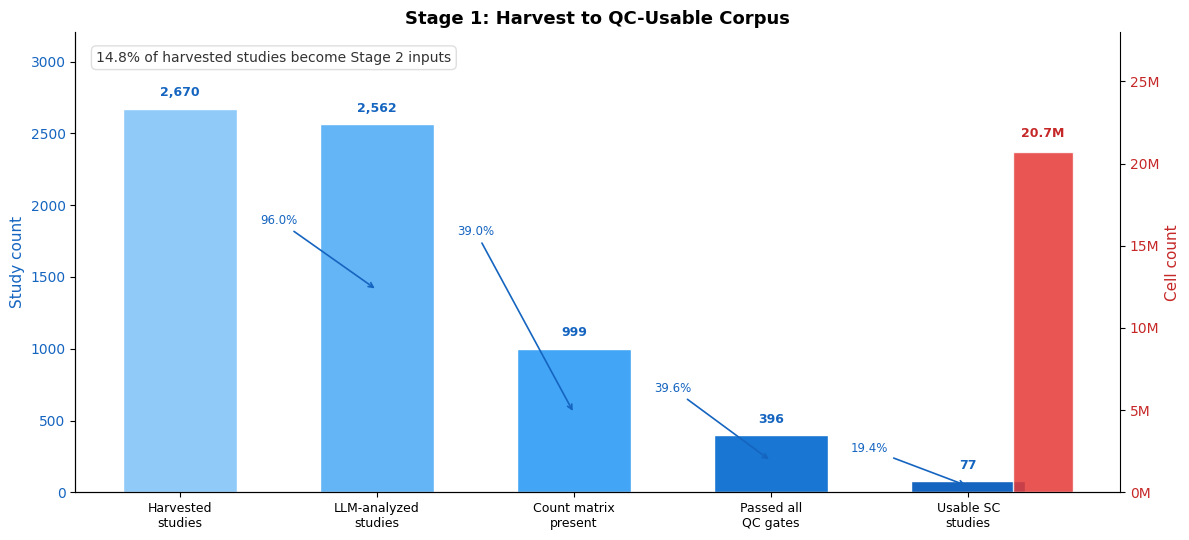

In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))

stages = [
    'Harvested\nstudies',
    'LLM-analyzed\nstudies',
    'Count matrix\npresent',
    'Passed all\nQC gates',
    'Usable SC\nstudies',
]
study_vals = [n_harvested, n_llm, n_matrix, n_usable, n_sc]
colors = ['#90CAF9', '#64B5F6', '#42A5F5', '#1976D2', '#1565C0']
x = np.arange(len(stages))

bars = ax.bar(x, study_vals, color=colors, edgecolor='white', width=0.58)
for bar, value in zip(bars, study_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(study_vals) * 0.025,
        f'{value:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#1565C0',
    )

for i in range(1, len(study_vals)):
    retained = study_vals[i] / study_vals[i - 1] * 100
    ax.annotate(
        f'{retained:.1f}%',
        xy=(x[i], study_vals[i] * 0.55),
        xytext=((x[i - 1] + x[i]) / 2, study_vals[i - 1] * 0.70),
        arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.2),
        ha='center',
        fontsize=8.5,
        color='#1565C0',
    )

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel('Study count', color='#1565C0', fontsize=11)
ax.tick_params(axis='y', labelcolor='#1565C0')
ax.set_ylim(0, max(study_vals) * 1.20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = ax.twinx()
cell_x = x[-1] + 0.38
ax2.bar(cell_x, sc_cells, width=0.30, color='#E53935', alpha=0.86, edgecolor='white', label='Usable SC cells')
ax2.text(cell_x, sc_cells + sc_cells * 0.035, f'{sc_cells/1e6:.1f}M',
         ha='center', va='bottom', fontsize=9, fontweight='bold', color='#C62828')
ax2.set_ylabel('Cell count', color='#C62828', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C62828')
ax2.set_ylim(0, sc_cells * 1.35)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value/1e6:.0f}M'))
ax2.spines['top'].set_visible(False)

ax.text(
    0.02,
    0.96,
    f'{n_usable/n_harvested*100:.1f}% of harvested studies become Stage 2 inputs',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color='#333333',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#DDDDDD', alpha=0.94),
)

ax.set_title('Stage 1: Harvest to QC-Usable Corpus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage Summary

Stage 1 establishes provenance from source database records to the final set of usable studies. The reported counts distinguish harvested studies, studies with parseable matrices, and studies passing all quality-control gates; the retained single-cell studies provide the expression corpus used in Stage 2.


---
## Reproducibility Notes

| Item | Value |
|------|-------|
| Python version | 3.12 |
| Key packages | `scanpy`, `anndata`, `pybiomart`, `pandas`, `scipy` |
| Ensembl BioMart release | 113 |
| Genome assembly | mRatBN7.2 (*Rattus norvegicus*) |
| BioMart fetch date | 2026-02-24 |
| GEO / ArrayExpress harvest date | 2026-01-18 |
| LLM analysis date | 2026-01-20 |
| Config file | `config/pipeline_config.yaml` — `biomart.ensembl_release: 113` |

**To re-run Stage 1 from scratch:**
```bash
export PIPELINE_ROOT=..
source motrpac-env/bin/activate
python pipeline/run_stage1.py                    # full run
python pipeline/run_stage1.py --skip-llm         # skip LLM steps (7, 10)
python pipeline/run_stage1.py --from 5           # resume from step 5
python pipeline/run_stage1.py --dry-run          # preview without executing
```

**Known considerations:**
- GEO and ArrayExpress harvest times are long (hours to days for ~2,600 studies). The `--skip-existing` flag skips studies already downloaded.
- The LLM step (step 7) consumes API credits proportional to the number of studies. Use `--only 7` to run it independently after the rest of the catalog is built.
- The 27 studies excluded during matrix analysis (step 5) as non-rat are logged in `data/catalog/matrix_analysis.json` under `excluded_non_rat`.
